<a href="https://colab.research.google.com/github/rkk7452/GIM_TEC_Extraction/blob/main/Extract_GIM_TEC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Extract the GIM files

In [1]:
pip install gnssanalysis

In [2]:
import numpy as np
import pandas as pd
import os
import re
import xarray
from gnssanalysis import gn_io
from datetime import datetime
import pytz
import scipy
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [3]:

# Needed if running on Google Colab only
# Gives access to data stored on Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [4]:
folder_path = "/content/drive/MyDrive/Caltech SRC '26/OVRO-LWA Data/" # where raw fits.fz files are
ryan_folder_path = "/content/drive/MyDrive/Caltech SRC '26/Output/" # where to export plots and data to
short_int_folder = "/content/drive/MyDrive/Caltech SRC '26/Short-Integrated-Sources-Catalog/" # where the short int source files are
output_path = "/content/drive/MyDrive/Caltech SRC '26/GIM-Interpolations/"


In [5]:
#Fields to change:

date = "2025-05-08" # format: YYYY-MM-DD
frequencies = [64,69,78,82] # full range: 18,23,27,32,36,41,46,55,59,64,69,78,82

In [12]:
#Convert date to all needed forms throughout program

date_object = datetime.strptime(date, "%Y-%m-%d") # convert to date object
day_num = date_object.timetuple().tm_yday # get the day number (1-365)
year_num = date_object.year # get the year
date_short = date.replace("-", "")

In [7]:
from google.colab import files
uploaded = files.upload() # upload the files

"""
Using:

IGS0OPSFIN_YYYYDDD0000_01D_02H_GIM.INX    Final product, 2 hour resolution
UPC0OPSRAP_YYYYDDD0000_01D_02H_GIM.INX    Rapid product, 2 hour resolution
UPC0OPSRAP_YYYYDDD0000_01D_01H_GIM.INX    Rapid product, 1 hour resolution
UPC0OPSRAP_YYYYDDD0000_01D_15M_GIM.INX    Rapid product, 15 min resolution

"""

Saving IGS0OPSFIN_20251280000_01D_02H_GIM.INX to IGS0OPSFIN_20251280000_01D_02H_GIM (3).INX
Saving UPC0OPSRAP_20251280000_01D_01H_GIM.INX to UPC0OPSRAP_20251280000_01D_01H_GIM (3).INX
Saving UPC0OPSRAP_20251280000_01D_02H_GIM.INX to UPC0OPSRAP_20251280000_01D_02H_GIM (2).INX
Saving UPC0OPSRAP_20251280000_01D_15M_GIM.INX to UPC0OPSRAP_20251280000_01D_15M_GIM (3).INX


'\nUsing:\n\nIGS0OPSFIN_20251270000_01D_02H_GIM.INX   Final product, 2 hour resolution\nUPC0OPSRAP_20251270000_01D_02H_GIM.INX    Rapid product, 2 hour resolution\nUPC0OPSRAP_20251270000_01D_01H_GIM.INX    Rapid product, 1 hour resolution\nUPC0OPSRAP_20251270000_01D_15M_GIM.INX    Rapid product, 15 min resolution\n\n'

In [8]:
ionex_2hr = gn_io.ionex.read_ionex(f"/content/IGS0OPSFIN_{year_num}{day_num}0000_01D_02H_GIM.INX")
ionex_2hr_r = gn_io.ionex.read_ionex(f"/content/UPC0OPSRAP_{year_num}{day_num}0000_01D_02H_GIM.INX")
ionex_1hr = gn_io.ionex.read_ionex(f"/content/UPC0OPSRAP_{year_num}{day_num}0000_01D_01H_GIM.INX")
ionex_15m = gn_io.ionex.read_ionex(f"/content/UPC0OPSRAP_{year_num}{day_num}0000_01D_15M_GIM.INX")

In [9]:
targetLat = 37.5 # closest to 37.239777271
targetLon = -120 # closest to -118.281666695
minTime = f"{date} 00:00:00" # earliest time we want
maxTime = f"{date} 23:59:59" # latest time we want
originTime = pd.Timestamp('2000-01-01 12:00:00') # seconds-based time is seconds after the originTime

# to keep the numerical values for interpolating later, the "Time" column is the seconds after noon, Jan 1, 2000.
#The "DateTime" column is the datetime object created from the "Time column"


#2 hour final dataset
epoch_2h = ionex_2hr.index.get_level_values("DateTime").unique()[0] # get time values (in seconds after noon on jan 1 2000)

tec_df_2h = (
    ionex_2hr
    .xs("TEC", level="Type")      # Keep only TEC rows
    .stack()                      # Turn longitude columns into rows
    .reset_index()                # Convert index levels to columns
    .rename(columns={0: "TEC"})   # Name the TEC values
    .rename(columns={'DateTime': "Time"}) # rename to time, the seconds after noon jan 1 2000
)
tec_df_2h["DateTime"] = pd.to_datetime(tec_df_2h["Time"], unit="s", origin = originTime, utc=True) # convert to formatted times

ovro_tec_2h = tec_df_2h[(tec_df_2h['Lat'] == targetLat) &
                        (tec_df_2h['Lon'] == targetLon) &
                        (tec_df_2h["DateTime"] >= minTime) &
                        (tec_df_2h["DateTime"] <= maxTime)] # filter to only rows at the correct position and time

#2 hour rapid dataset
epoch_2h_r = ionex_2hr_r.index.get_level_values("DateTime").unique()[0] # get time values (in seconds after noon on jan 1 2000)

tec_df_2h_r = (
    ionex_2hr_r
    .xs("TEC", level="Type")      # Keep only TEC rows
    .stack()                      # Turn longitude columns into rows
    .reset_index()                # Convert index levels to columns
    .rename(columns={0: "TEC"})   # Name the TEC values
    .rename(columns={'DateTime': "Time"}) # rename to time, the seconds after noon jan 1 2000
)
tec_df_2h_r["DateTime"] = pd.to_datetime(tec_df_2h_r["Time"], unit="s", origin = originTime, utc=True) # convert to formatted times

ovro_tec_2h_r = tec_df_2h_r[(tec_df_2h_r['Lat'] == targetLat) &
                        (tec_df_2h_r['Lon'] == targetLon) &
                        (tec_df_2h_r["DateTime"] >= minTime) &
                        (tec_df_2h_r["DateTime"] <= maxTime)] # filter to only rows at the correct position and time


#1 hour rapid dataset
epoch_1h = ionex_1hr.index.get_level_values("DateTime").unique()[0] # get time values (in seconds after noon on jan 1 2000)

tec_df_1h = (
    ionex_1hr
    .xs("TEC", level="Type")      # Keep only TEC rows
    .stack()                      # Turn longitude columns into rows
    .reset_index()                # Convert index levels to columns
    .rename(columns={0: "TEC"})   # Name the TEC values
    .rename(columns={'DateTime': "Time"}) # rename to time, the seconds after noon jan 1 2000
)
tec_df_1h["DateTime"] = pd.to_datetime(tec_df_1h["Time"], unit="s", origin = originTime, utc=True) # convert to formatted times

ovro_tec_1h = tec_df_1h[(tec_df_1h['Lat'] == targetLat) &
                        (tec_df_1h['Lon'] == targetLon) &
                        (tec_df_1h["DateTime"] >= minTime) &
                        (tec_df_1h["DateTime"] <= maxTime)] # filter to only rows at the correct position and time


#15 min rapid dataset
epoch_15m = ionex_15m.index.get_level_values("DateTime").unique()[0] # get time values (in seconds after noon on jan 1 2000)

tec_df_15m = (
    ionex_15m
    .xs("TEC", level="Type")      # Keep only TEC rows
    .stack()                      # Turn longitude columns into rows
    .reset_index()                # Convert index levels to columns
    .rename(columns={0: "TEC"})   # Name the TEC values
    .rename(columns={'DateTime': "Time"}) # rename to time, the seconds after noon jan 1 2000
)
tec_df_15m["DateTime"] = pd.to_datetime(tec_df_15m["Time"], unit="s", origin = originTime, utc=True) # convert to formatted times

ovro_tec_15m = tec_df_15m[(tec_df_15m['Lat'] == targetLat) &
                        (tec_df_15m['Lon'] == targetLon) &
                        (tec_df_15m["DateTime"] >= minTime) &
                        (tec_df_15m["DateTime"] <= maxTime)] # filter to only rows at the correct position and time

#display all
display(ovro_tec_2h.head())
display(ovro_tec_2h_r.head())
display(ovro_tec_1h.head())
display(ovro_tec_15m.head())

,Time,Lat,Lon,TEC,DateTime
1472,799934400,37.5,-120.0,34.6,2025-05-08 00:00:00+00:00
6655,799941600,37.5,-120.0,30.8,2025-05-08 02:00:00+00:00
11838,799948800,37.5,-120.0,24.3,2025-05-08 04:00:00+00:00
17021,799956000,37.5,-120.0,16.9,2025-05-08 06:00:00+00:00
22204,799963200,37.5,-120.0,15.3,2025-05-08 08:00:00+00:00


,Time,Lat,Lon,TEC,DateTime
1472,799934400,37.5,-120.0,30.6,2025-05-08 00:00:00+00:00
6655,799941600,37.5,-120.0,27.2,2025-05-08 02:00:00+00:00
11838,799948800,37.5,-120.0,21.9,2025-05-08 04:00:00+00:00
17021,799956000,37.5,-120.0,14.3,2025-05-08 06:00:00+00:00
22204,799963200,37.5,-120.0,13.7,2025-05-08 08:00:00+00:00


,Time,Lat,Lon,TEC,DateTime
1472,799934400,37.5,-120.0,29.1,2025-05-08 00:00:00+00:00
6655,799938000,37.5,-120.0,27.7,2025-05-08 01:00:00+00:00
11838,799941600,37.5,-120.0,27.5,2025-05-08 02:00:00+00:00
17021,799945200,37.5,-120.0,24.2,2025-05-08 03:00:00+00:00
22204,799948800,37.5,-120.0,20.2,2025-05-08 04:00:00+00:00


,Time,Lat,Lon,TEC,DateTime
1472,799934400,37.5,-120.0,29.1,2025-05-08 00:00:00+00:00
6655,799935300,37.5,-120.0,29.5,2025-05-08 00:15:00+00:00
11838,799936200,37.5,-120.0,29.4,2025-05-08 00:30:00+00:00
17021,799937100,37.5,-120.0,28.8,2025-05-08 00:45:00+00:00
22204,799938000,37.5,-120.0,27.7,2025-05-08 01:00:00+00:00


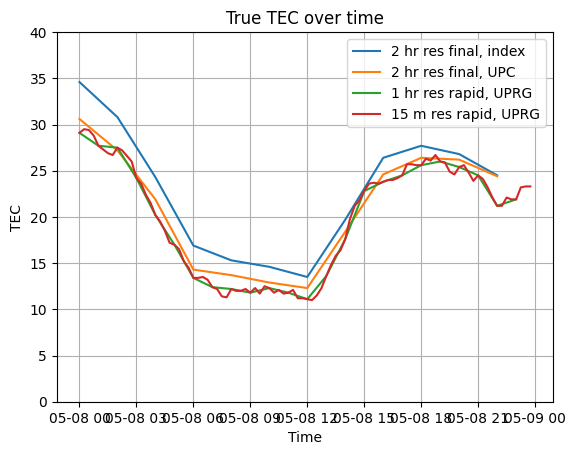

In [10]:
a = ovro_tec_2h.copy().drop(columns=['Lat','Lon']) # 2 hour final, index
b = ovro_tec_2h_r.copy().drop(columns=['Lat','Lon']) # 2 hour final, UPC
c = ovro_tec_1h.copy().drop(columns=['Lat','Lon']) # 1 hour rapid
d = ovro_tec_15m.copy().drop(columns=['Lat','Lon']) # 15 min rapid, potentially lower quality UPRG

fig, ax = plt.subplots()
ax.plot(a['DateTime'], a['TEC'], label = '2 hr res final, index')
ax.plot(b['DateTime'], b['TEC'], label = '2 hr res final, UPC')
ax.plot(c['DateTime'], c['TEC'], label = '1 hr res rapid, UPRG')
ax.plot(d['DateTime'], d['TEC'], label = '15 m res rapid, UPRG')

ax.set_ylim(0,40)

ax.set(xlabel='Time', ylabel='TEC',
       title='True TEC over time')
ax.grid()

plt.legend(loc="upper right")

plt.show()

# Extract Timestamps from Combined CSV File, Interpolate, and export CSV

     source_id          ra        dec  total_flux     azimuth  elevation  \
0            0 -100.006915  -0.883632   77.444097   98.498389   9.522693   
818        818 -187.684958  10.168159    9.586423  201.631912  61.220964   
817        817 -201.632617  58.244197   46.912648  330.575415  63.798956   
816        816 -192.108680  40.821442   18.274126  291.264026  78.017175   
815        815 -187.509687  11.794154    7.090693  202.332948  62.822784   

                                           file_name  
0    64MHz-Clean-Snapshot-20250508_050007-image.fits  
818  64MHz-Clean-Snapshot-20250508_050007-image.fits  
817  64MHz-Clean-Snapshot-20250508_050007-image.fits  
816  64MHz-Clean-Snapshot-20250508_050007-image.fits  
815  64MHz-Clean-Snapshot-20250508_050007-image.fits  


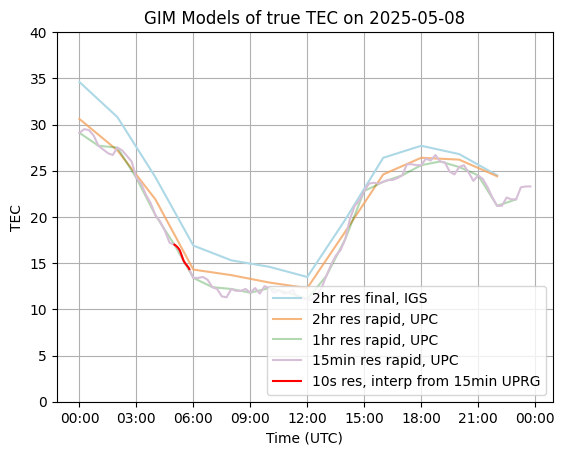

Completed all frequencies. Time Finished: Jul 22, 2026 at 10:06:12
        source_id          ra        dec  total_flux     azimuth  elevation  \
198023     198023  -99.974143  -0.923015   72.212474   98.535339   9.505486   
198670     198670 -231.135440  72.652283    6.307655  339.717405  45.981085   
198671     198671 -252.742869  74.845415   20.203660  340.810495  39.642433   
198672     198672 -187.670023  10.178676    8.548185  201.690840  61.223108   
198673     198673 -244.578959  74.256094   10.105243  340.352697  41.866835   

                                              file_name  
198023  69MHz-Clean-Snapshot-20250508_050017-image.fits  
198670  69MHz-Clean-Snapshot-20250508_050017-image.fits  
198671  69MHz-Clean-Snapshot-20250508_050017-image.fits  
198672  69MHz-Clean-Snapshot-20250508_050017-image.fits  
198673  69MHz-Clean-Snapshot-20250508_050017-image.fits  


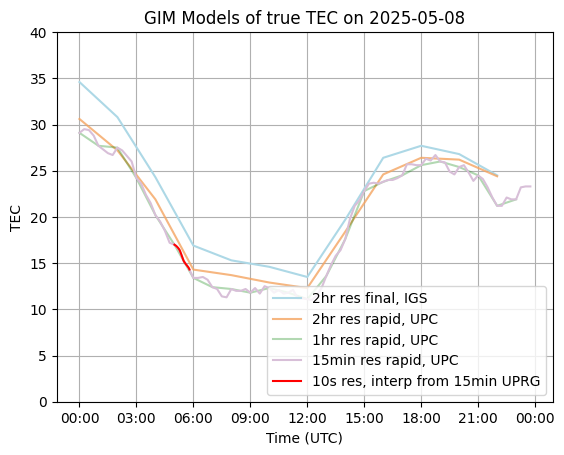

Completed all frequencies. Time Finished: Jul 22, 2026 at 10:06:14
     source_id          ra        dec  total_flux     azimuth  elevation  \
0            0  -99.989905  -0.930521   75.806787   98.525090   9.480336   
471        471 -185.636752   1.262133    7.347903  193.964113  53.070553   
472        472 -186.421891 -17.427763    9.020361  190.578412  34.518258   
473        473 -186.633842 -19.893577    9.584000  190.365788  32.050511   
474        474 -262.530784  76.562637    5.714920  343.077063  37.284476   

                                           file_name  
0    78MHz-Clean-Snapshot-20250508_050007-image.fits  
471  78MHz-Clean-Snapshot-20250508_050007-image.fits  
472  78MHz-Clean-Snapshot-20250508_050007-image.fits  
473  78MHz-Clean-Snapshot-20250508_050007-image.fits  
474  78MHz-Clean-Snapshot-20250508_050007-image.fits  


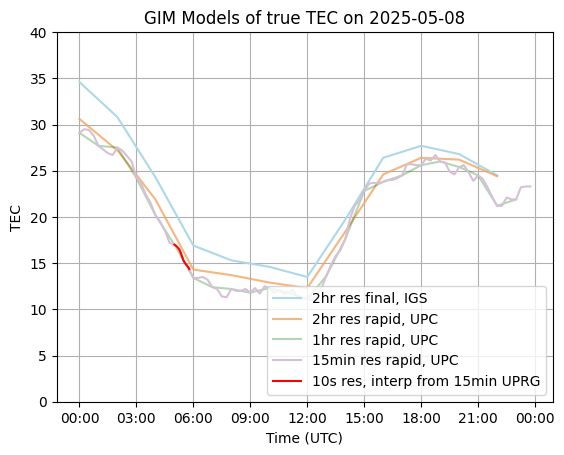

Completed all frequencies. Time Finished: Jul 22, 2026 at 10:06:15
     source_id          ra        dec  total_flux     azimuth  elevation  \
0            0  -99.929487  -0.987508   60.875640   98.532627   9.397627   
251        251 -211.056754  69.684222   17.697624  341.296685  53.003396   
250        250 -185.221449 -13.808208   14.856829  189.815262  38.268215   
249        249 -184.727500   1.251132   14.366200  192.470214  53.225017   
248        248 -184.726050   5.757772    7.305511  193.912688  57.657390   

                                           file_name  
0    82MHz-Clean-Snapshot-20250508_050007-image.fits  
251  82MHz-Clean-Snapshot-20250508_050007-image.fits  
250  82MHz-Clean-Snapshot-20250508_050007-image.fits  
249  82MHz-Clean-Snapshot-20250508_050007-image.fits  
248  82MHz-Clean-Snapshot-20250508_050007-image.fits  


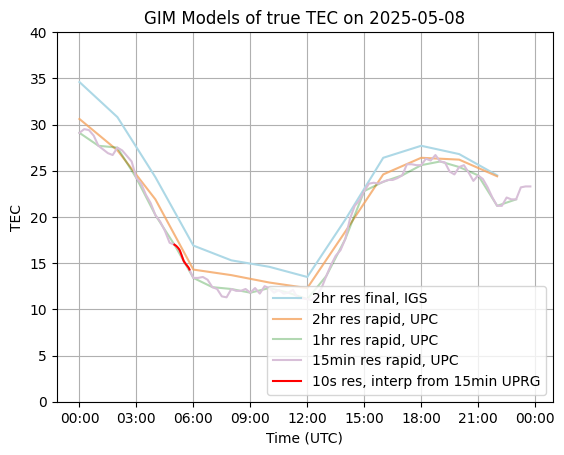

Completed all frequencies. Time Finished: Jul 22, 2026 at 10:06:16


In [15]:
# loopable version

for freq in frequencies:
  df = pd.read_csv(os.path.join(ryan_folder_path, short_int_folder, date_short, f"combined_sources_{freq}MHz_{date_short}.csv"))
  df = df.sort_values(by='file_name',ascending=True)
  print(df.head())
  times_df = df.copy().drop(columns=['source_id','ra','dec','total_flux','azimuth','elevation'])

  times_df['dt'] = pd.to_datetime(
      times_df['file_name'].str.extract(r'(\d{8}_\d{6})')[0],
      format='%Y%m%d_%H%M%S'
  )
  times_df = times_df.drop(columns=['file_name'])
  times_df = times_df.drop_duplicates().reset_index(drop=True)
  times_df['dt'] = (times_df['dt'] - originTime).dt.total_seconds().to_numpy()

  #display(times_df)

  #interpolate into 10 second intervals to match OVRO-LWA data

  pchip = scipy.interpolate.PchipInterpolator(d['Time'],d['TEC'], extrapolate=False)
  data_seconds = times_df['dt'].to_numpy()
  gim_tec_arr = pchip(data_seconds)

  gim_tec = pd.DataFrame({
      "DateTime": pd.to_datetime(times_df["dt"], unit="s", origin = originTime, utc=True),
      "TEC": gim_tec_arr
  })

  #plot again with interpolated values
  a = ovro_tec_2h.copy().drop(columns=['Lat','Lon']) # 2 hour final, IGS
  b = ovro_tec_2h_r.copy().drop(columns=['Lat','Lon']) # 2 hour rapid, UPC
  c = ovro_tec_1h.copy().drop(columns=['Lat','Lon']) # 1 hour rapid, UPC
  d = ovro_tec_15m.copy().drop(columns=['Lat','Lon']) # 15 min rapid, UPC
  e = gim_tec

  fig, ax = plt.subplots()
  ax.plot(a['DateTime'], a['TEC'], label = '2hr res final, IGS', alpha=1, c='lightblue')
  ax.plot(b['DateTime'], b['TEC'], label = '2hr res rapid, UPC', alpha=0.8, c='sandybrown')
  ax.plot(c['DateTime'], c['TEC'], label = '1hr res rapid, UPC', alpha=0.3, c='green')
  ax.plot(d['DateTime'], d['TEC'], label = '15min res rapid, UPC', alpha=1, c='thistle')
  ax.plot(e['DateTime'], e['TEC'], label = '10s res, interp from 15min UPRG', c='red')

  ax.set_ylim(0,40)

  ax.set(xlabel='Time (UTC)', ylabel='TEC',
        title=f'GIM Models of true TEC on {date}')
  ax.grid()
  ax.xaxis.set_major_locator(mdates.HourLocator(byhour=range(0, 24, 3))) # tick every 3 hours between 0 and 24
  ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M')) # For hours
  plt.legend(loc="lower right")

  plt.show()

  combined_csv_path = os.path.join(output_path, str(date_short), f"{date_short}_{freq}MHz_GIM_TEC.csv")
  gim_tec.to_csv(combined_csv_path, index=False)

  print(f"Completed all frequencies. Time Finished: {datetime.now(pytz.timezone("US/Pacific")).strftime("%b %d, %Y at %H:%M:%S")}")